# Choose best model

In [5]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("miniLAVAD_V3")

best_val_loss = float('inf')
best_run_id = None
best_epoch = None
best_lr = None

for run in client.search_runs(experiment.experiment_id):
    lr = run.data.params.get('training.learning_rate', 'unknown')
    val_losses = client.get_metric_history(run.info.run_id, "val_loss")

    for metric in val_losses:
        if metric.value < best_val_loss:
            best_val_loss = metric.value
            best_run_id = run.info.run_id
            best_epoch = metric.step + 1
            best_lr = lr

print(f"=== BEST MODEL FOUND ===")
print(f"Learning Rate: {best_lr}")
print(f"Run ID:        {best_run_id}")
print(f"Epoch:         {best_epoch}")
print(f"Val Loss:      {best_val_loss:.4f}")
print("========================")
print(f"Evaluation Command:")
print(f"python src/evaluate.py --run_id {best_run_id} --epoch checkpoints_epoch_{best_epoch}")

=== BEST MODEL FOUND ===
Learning Rate: unknown
Run ID:        9c8e54a85e604ab388e44076b9734808
Epoch:         4
Val Loss:      1.2432
Evaluation Command:
python src/evaluate.py --run_id 9c8e54a85e604ab388e44076b9734808 --epoch checkpoints_epoch_4


# Calculate AUC

In [8]:
import json
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score

# Ensure scikit-learn is installed: pip install scikit-learn
PROJECT_ROOT = Path.cwd().parent

def calculate_auc(test_json_path, results_json_path):
    print("Loading ground truth and predictions...")
    
    with open(test_json_path, 'r') as f:
        ground_truth_data = json.load(f)
        
    with open(results_json_path, 'r') as f:
        results_data = json.load(f)

    y_true_all = []
    y_pred_all = []

    # Map ground truth by video filename
    gt_map = {Path(item["video_path"]).stem: item for item in ground_truth_data}

    for video_id, predicted_scores in results_data["scores"].items():
        if video_id not in gt_map:
            continue
            
        gt_item = gt_map[video_id]
        label = gt_item["label"]
        total_frames = len(predicted_scores)
        
        # Create frame-level ground truth array
        frame_labels = np.zeros(total_frames)
        
        if label != "Normal":
            # If we have precise crime_start and crime_end in the JSON
            start_sec = gt_item.get("crime_start", 0.0)
            end_sec = gt_item.get("crime_end", 0.0)
            
            # Estimate frame indices (assuming 30fps for standard UCF-Crime, 
            # though the exact math depends on decord's extraction)
            # A simpler approximation for ROC is to treat the whole anomaly video 
            # as 1s if frame-level GT isn't perfectly mapped, but let's try frame-level:
            fps = 30.0 
            start_idx = min(int(start_sec * fps), total_frames - 1)
            end_idx = min(int(end_sec * fps), total_frames - 1)
            
            if start_idx < end_idx:
                frame_labels[start_idx:end_idx] = 1.0
            else:
                # Fallback: flag the whole video if timestamps are missing
                frame_labels[:] = 1.0 

        y_true_all.extend(frame_labels.tolist())
        y_pred_all.extend(predicted_scores)

    if not y_true_all:
        print("Error: Could not match any videos between results and ground truth.")
        return

    # Calculate global Frame-Level AUC-ROC
    auc_score = roc_auc_score(y_true_all, y_pred_all)
    
    print("\n" + "="*40)
    print(f"Total Frames Evaluated: {len(y_true_all)}")
    print(f"Global Frame-Level AUC-ROC: {auc_score:.4f}")
    print("="*40 + "\n")
    
    if auc_score < 0.60:
        print("⚠️ Warning: Score is near random chance. The model likely collapsed to predicting 'Yes' for everything.")

if __name__ == "__main__":
    files_to_evaluate = ['val_base_eval_9c8e54_checkpoints_epoch_3.json','val_base_eval_9c8e54_checkpoints_epoch_4.json','val_base_eval_8718c5_checkpoints_epoch_3.json','val_base_eval_8718c5_checkpoints_epoch_4.json','val_base_eval_310989_checkpoints_epoch_3.json','val_base_eval_310989_checkpoints_epoch_4.json',
'val_base_eval_vanilla.json']
    test_json = PROJECT_ROOT / "data" / "processed" / "val_split.json"
    for file in files_to_evaluate:
        print(f"Evaluating {file}")
        results_json = PROJECT_ROOT / "models" / file
        calculate_auc(test_json, results_json)

Evaluating val_base_eval_9c8e54_checkpoints_epoch_3.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.6183

Evaluating val_base_eval_9c8e54_checkpoints_epoch_4.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.6178

Evaluating val_base_eval_8718c5_checkpoints_epoch_3.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.7060

Evaluating val_base_eval_8718c5_checkpoints_epoch_4.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.7369

Evaluating val_base_eval_310989_checkpoints_epoch_3.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.7147

Evaluating val_base_eval_310989_checkpoints_epoch_4.json
Loading ground truth and predictions...

Total Frames Evaluated: 1589684
Global Frame-Level AUC-ROC: 0.5800

⚠️ W

# Choose temperature and Youden's J

In [5]:
import json
import os
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path

# Ensure scikit-learn is installed: pip install scikit-learn
PROJECT_ROOT = Path.cwd().parent

def apply_dynamic_boundaries(raw_scores, total_frames, window_size=60, suppression_power=2.0):
    """Replication of your evaluation script's smoothing logic, WITHOUT max scaling."""
    if len(raw_scores) == 0:
        return np.zeros(total_frames).tolist()

    frame_level_raw = np.interp(
        np.arange(total_frames),
        np.linspace(0, total_frames - 1, len(raw_scores)),
        raw_scores
    )

    if window_size > 1:
        smoothed = np.convolve(frame_level_raw, np.ones(window_size) / window_size, mode='same')
    else:
        smoothed = frame_level_raw

    if suppression_power != 1.0:
        amplified = smoothed ** suppression_power
    else:
        amplified = smoothed

    # REMOVED: Do not force the max value to 1.0, let the absolute probabilities stand!
    # max_val = np.max(amplified)
    # if max_val > 0:
    #     amplified = amplified / max_val

    return amplified.tolist()

def softmax(logits, temperature=1.0):
    """Applies temperature-scaled softmax to a list of [yes_logit, no_logit]."""
    scaled = np.array(logits) / temperature
    exp_scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
    probs = exp_scaled / np.sum(exp_scaled, axis=1, keepdims=True)
    return probs[:, 0]

def optimize_hyperparameters():
    val_json_path = PROJECT_ROOT / "data/processed/val_split.json"
    with open(val_json_path, "r") as f:
        val_data = json.load(f)

    gt_lookup = {}
    for item in val_data:
        video_id = item.get("video_id", os.path.splitext(os.path.basename(item["video_path"]))[0])
        anomaly_segments = []
        duration = None
        if "uca_data" in item and "timestamps" in item["uca_data"]:
            anomaly_segments = item["uca_data"]["timestamps"]
            duration = item["uca_data"].get("duration")
        elif "temporal_segments_sec" in item:
            anomaly_segments = item["temporal_segments_sec"]

        gt_lookup[video_id] = {
            "label": item["label"],
            "is_abnormal": item["label"] != "Normal",
            "segments_sec": anomaly_segments,
            "duration": duration
        }

    # IMPORTANT: Update path if running from notebooks dir vs root dir
    best_eval_file = PROJECT_ROOT / "models/val_base_eval_8718c5_checkpoints_epoch_4.json"
    print(f"Loading raw logits from {best_eval_file}...")
    with open(best_eval_file, "r") as f:
        eval_data = json.load(f)

    raw_captions = eval_data.get("raw_captions", {})
    video_frame_counts = {vid: len(scores) for vid, scores in eval_data.get("scores", {}).items()}

    temperatures = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.5, 10.0]
    window_size = 60
    suppression_power = 2.0

    print(f"\n{'Temperature':<12} | {'AUC':<10} | {'Best Threshold':<15} | {'J-Statistic':<12}")
    print("-" * 55)

    best_overall_auc = 0
    best_overall_params = {}

    for temp in temperatures:
        all_gt = []
        all_preds = []

        for video_id, logs in raw_captions.items():
            if video_id not in gt_lookup or video_id not in video_frame_counts:
                continue

            logits_list = [[log["raw_logits"]["yes"], log["raw_logits"]["no"]] for log in logs if "raw_logits" in log]
            if not logits_list:
                continue

            chunk_probs = softmax(logits_list, temperature=temp)
            total_frames = video_frame_counts[video_id]
            frame_scores = apply_dynamic_boundaries(
                raw_scores=chunk_probs,
                total_frames=total_frames,
                window_size=window_size,
                suppression_power=suppression_power
            )

            gt_info = gt_lookup[video_id]
            video_gt = np.zeros(total_frames, dtype=int)

            if gt_info["is_abnormal"] and gt_info["segments_sec"]:
                fps = total_frames / gt_info["duration"] if gt_info["duration"] else 30.0
                for segment in gt_info["segments_sec"]:
                    if len(segment) == 2:
                        start_sec, end_sec = segment
                        video_gt[max(0, int(start_sec * fps)):min(total_frames, int(end_sec * fps))] = 1

            all_gt.extend(video_gt)
            all_preds.extend(frame_scores)

        if len(all_gt) > 0:
            auc = roc_auc_score(all_gt, all_preds)
            fpr, tpr, thresholds = roc_curve(all_gt, all_preds)
            j_scores = tpr - fpr
            best_idx = np.argmax(j_scores)
            best_threshold = thresholds[best_idx]
            best_j = j_scores[best_idx]

            print(f"{temp:<12.1f} | {auc:<10.4f} | {best_threshold:<15.4f} | {best_j:<12.4f}")

            if auc > best_overall_auc:
                best_overall_auc = auc
                best_overall_params = {
                    "temperature": temp,
                    "threshold": best_threshold,
                    "auc": auc
                }

    print("-" * 55)
    print(f"🌟 Optimal Temperature: {best_overall_params['temperature']}")
    print(f"🌟 Optimal Threshold for Classification: {best_overall_params['threshold']:.4f}")

if __name__ == "__main__":
    optimize_hyperparameters()

Loading raw logits from /hdd/Documents/Projects/miniLAVAD/models/val_base_eval_8718c5_checkpoints_epoch_4.json...

Temperature  | AUC        | Best Threshold  | J-Statistic 
-------------------------------------------------------
1.0          | 0.7375     | 1.0000          | 0.4396      
2.0          | 0.7375     | 1.0000          | 0.4396      
3.0          | 0.7375     | 1.0000          | 0.4396      
4.0          | 0.7375     | 1.0000          | 0.4396      
5.0          | 0.7375     | 1.0000          | 0.4396      
6.0          | 0.7375     | 1.0000          | 0.4396      
7.5          | 0.7375     | 1.0000          | 0.4396      
10.0         | 0.7375     | 1.0000          | 0.4396      
-------------------------------------------------------
🌟 Optimal Temperature: 1.0
🌟 Optimal Threshold for Classification: 1.0000


# Choose window size and suppression power

In [14]:
import json
import os
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path

# Adjust this if you are running from inside a notebook vs the root directory
PROJECT_ROOT = Path.cwd().parent

def apply_dynamic_boundaries(raw_scores, total_frames, window_size=60, suppression_power=2.0):
    """Replication of your evaluation script's smoothing logic, WITHOUT max scaling."""
    if len(raw_scores) == 0:
        return np.zeros(total_frames).tolist()

    # Stretch to match frame count exactly
    frame_level_raw = np.interp(
        np.arange(total_frames),
        np.linspace(0, total_frames - 1, len(raw_scores)),
        raw_scores
    )

    # Smooth
    if window_size > 1:
        smoothed = np.convolve(frame_level_raw, np.ones(window_size) / window_size, mode='same')
        # ENSURE EXACT LENGTH MATCH
        smoothed = smoothed[:total_frames]
    else:
        smoothed = frame_level_raw

    # Suppress noise
    if suppression_power != 1.0:
        amplified = smoothed ** suppression_power
    else:
        amplified = smoothed

    return amplified.tolist()

def softmax(logits, temperature=1.0):
    """Applies temperature-scaled softmax to a list of [yes_logit, no_logit]."""
    scaled = np.array(logits) / temperature
    exp_scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
    probs = exp_scaled / np.sum(exp_scaled, axis=1, keepdims=True)
    return probs[:, 0]

def optimize_smoothing():
    val_json_path = PROJECT_ROOT / "data/processed/val_split.json"
    with open(val_json_path, "r") as f:
        val_data = json.load(f)

    gt_lookup = {}
    for item in val_data:
        video_id = item.get("video_id", os.path.splitext(os.path.basename(item["video_path"]))[0])
        anomaly_segments = []
        duration = None
        if "uca_data" in item and "timestamps" in item["uca_data"]:
            anomaly_segments = item["uca_data"]["timestamps"]
            duration = item["uca_data"].get("duration")
        elif "temporal_segments_sec" in item:
            anomaly_segments = item["temporal_segments_sec"]

        gt_lookup[video_id] = {
            "label": item["label"],
            "is_abnormal": item["label"] != "Normal",
            "segments_sec": anomaly_segments,
            "duration": duration
        }

    # Best Validation Run
    best_eval_file = PROJECT_ROOT / "models/val_base_eval_8718c5_checkpoints_epoch_4.json"
    print(f"Loading raw logits from {best_eval_file}...\n")
    with open(best_eval_file, "r") as f:
        eval_data = json.load(f)

    raw_captions = eval_data.get("raw_captions", {})
    video_frame_counts = {vid: len(scores) for vid, scores in eval_data.get("scores", {}).items()}

    # Hyperparameter grids to search
    window_sizes = [1, 30, 60, 90, 120, 150, 180, 240, 300, 400, 500, 750, 1000]
    suppression_powers = [1.0, 2.0, 3.0]
    fixed_temperature = 1.0

    print(f"{'Window Size':<12} | {'Suppression':<12} | {'AUC':<10} | {'Best Threshold':<15}")
    print("-" * 55)

    best_overall_auc = 0
    best_overall_params = {}

    for window in window_sizes:
        for power in suppression_powers:
            all_gt = []
            all_preds = []

            for video_id, logs in raw_captions.items():
                if video_id not in gt_lookup or video_id not in video_frame_counts:
                    continue

                logits_list = [[log["raw_logits"]["yes"], log["raw_logits"]["no"]] for log in logs if "raw_logits" in log]
                if not logits_list:
                    continue

                # Softmax with fixed temp
                chunk_probs = softmax(logits_list, temperature=fixed_temperature)

                # Apply smoothing with current grid parameters
                total_frames = video_frame_counts[video_id]
                frame_scores = apply_dynamic_boundaries(
                    raw_scores=chunk_probs,
                    total_frames=total_frames,
                    window_size=window,
                    suppression_power=power
                )

                # Generate Ground Truth
                gt_info = gt_lookup[video_id]
                video_gt = np.zeros(total_frames, dtype=int)

                if gt_info["is_abnormal"] and gt_info["segments_sec"]:
                    fps = total_frames / gt_info["duration"] if gt_info["duration"] else 30.0
                    for segment in gt_info["segments_sec"]:
                        if len(segment) == 2:
                            start_sec, end_sec = segment
                            video_gt[max(0, int(start_sec * fps)):min(total_frames, int(end_sec * fps))] = 1

                all_gt.extend(video_gt)
                all_preds.extend(frame_scores)

            if len(all_gt) > 0:
                auc = roc_auc_score(all_gt, all_preds)
                fpr, tpr, thresholds = roc_curve(all_gt, all_preds)
                j_scores = tpr - fpr
                best_idx = np.argmax(j_scores)
                best_threshold = thresholds[best_idx]

                print(f"{window:<12} | {power:<12.1f} | {auc:<10.4f} | {best_threshold:<15.4f}")

                if auc > best_overall_auc:
                    best_overall_auc = auc
                    best_overall_params = {
                        "window_size": window,
                        "suppression_power": power,
                        "threshold": best_threshold,
                        "auc": auc
                    }

    print("-" * 55)
    print(f"🌟 Optimal Window Size: {best_overall_params['window_size']}")
    print(f"🌟 Optimal Suppression Power: {best_overall_params['suppression_power']}")
    print(f"🌟 Resulting Validation AUC: {best_overall_params['auc']:.4f}")

if __name__ == "__main__":
    optimize_smoothing()

Loading raw logits from /hdd/Documents/Projects/miniLAVAD/models/val_base_eval_8718c5_checkpoints_epoch_4.json...

Window Size  | Suppression  | AUC        | Best Threshold 
-------------------------------------------------------
1            | 1.0          | 0.7347     | 1.0000         
1            | 2.0          | 0.7347     | 1.0000         
1            | 3.0          | 0.7347     | 1.0000         
30           | 1.0          | 0.7363     | 1.0000         
30           | 2.0          | 0.7363     | 1.0000         
30           | 3.0          | 0.7363     | 1.0000         
60           | 1.0          | 0.7375     | 1.0000         
60           | 2.0          | 0.7375     | 1.0000         
60           | 3.0          | 0.7375     | 1.0000         
90           | 1.0          | 0.7384     | 1.0000         
90           | 2.0          | 0.7384     | 1.0000         
90           | 3.0          | 0.7384     | 1.0000         
120          | 1.0          | 0.7392     | 1.0000         
120

Loading raw logits from /hdd/Documents/Projects/miniLAVAD/models/val_base_eval_8718c5_checkpoints_epoch_4.json...

Window Size  | Validation AUC 
------------------------------
10           | 0.7353
30           | 0.7363
50           | 0.7372
70           | 0.7379
90           | 0.7384
110          | 0.7390
130          | 0.7394
150          | 0.7399
170          | 0.7403
190          | 0.7407
210          | 0.7411
230          | 0.7415
250          | 0.7419
270          | 0.7423
290          | 0.7426
310          | 0.7429
330          | 0.7430
350          | 0.7430
370          | 0.7431
390          | 0.7431
410          | 0.7431
430          | 0.7432
450          | 0.7432
470          | 0.7432
490          | 0.7433
510          | 0.7433
530          | 0.7434
550          | 0.7435
570          | 0.7436
590          | 0.7437
610          | 0.7439
630          | 0.7439
650          | 0.7439
670          | 0.7438
690          | 0.7437
710          | 0.7435
730          | 0.7434
750      

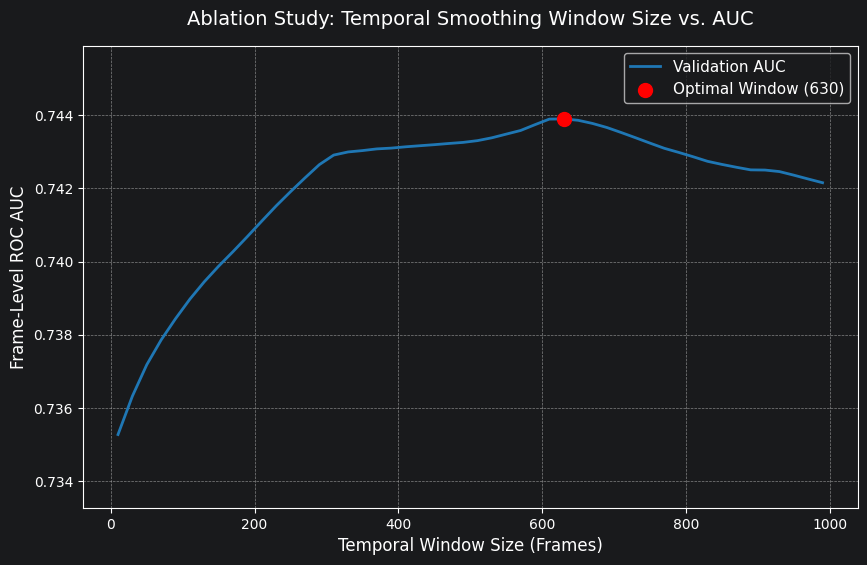


✅ High-resolution chart saved to: /hdd/Documents/Projects/miniLAVAD/smoothing_ablation_curve.png


<Figure size 640x480 with 0 Axes>

In [15]:
import json
import os
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from pathlib import Path
import matplotlib.pyplot as plt

# Adjust this if running from inside notebooks/ vs root directory
PROJECT_ROOT = Path.cwd().parent

def apply_dynamic_boundaries(raw_scores, total_frames, window_size=60, suppression_power=2.0):
    """Replication of your evaluation script's smoothing logic, WITHOUT max scaling."""
    if len(raw_scores) == 0:
        return np.zeros(total_frames).tolist()

    frame_level_raw = np.interp(
        np.arange(total_frames),
        np.linspace(0, total_frames - 1, len(raw_scores)),
        raw_scores
    )

    if window_size > 1:
        smoothed = np.convolve(frame_level_raw, np.ones(window_size) / window_size, mode='same')
        smoothed = smoothed[:total_frames]
    else:
        smoothed = frame_level_raw

    if suppression_power != 1.0:
        amplified = smoothed ** suppression_power
    else:
        amplified = smoothed

    return amplified.tolist()

def softmax(logits, temperature=1.0):
    """Applies temperature-scaled softmax to a list of [yes_logit, no_logit]."""
    scaled = np.array(logits) / temperature
    exp_scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
    probs = exp_scaled / np.sum(exp_scaled, axis=1, keepdims=True)
    return probs[:, 0]

def plot_ablation_curve():
    val_json_path = PROJECT_ROOT / "data/processed/val_split.json"
    with open(val_json_path, "r") as f:
        val_data = json.load(f)

    gt_lookup = {}
    for item in val_data:
        video_id = item.get("video_id", os.path.splitext(os.path.basename(item["video_path"]))[0])
        anomaly_segments = []
        duration = None
        if "uca_data" in item and "timestamps" in item["uca_data"]:
            anomaly_segments = item["uca_data"]["timestamps"]
            duration = item["uca_data"].get("duration")
        elif "temporal_segments_sec" in item:
            anomaly_segments = item["temporal_segments_sec"]

        gt_lookup[video_id] = {
            "label": item["label"],
            "is_abnormal": item["label"] != "Normal",
            "segments_sec": anomaly_segments,
            "duration": duration
        }

    best_eval_file = PROJECT_ROOT / "models/val_base_eval_8718c5_checkpoints_epoch_4.json"
    print(f"Loading raw logits from {best_eval_file}...\n")
    with open(best_eval_file, "r") as f:
        eval_data = json.load(f)

    raw_captions = eval_data.get("raw_captions", {})
    video_frame_counts = {vid: len(scores) for vid, scores in eval_data.get("scores", {}).items()}

    # HIGH RESOLUTION SWEEP: From 10 to 1000 in steps of 20
    window_sizes = list(range(10, 1001, 20))
    fixed_power = 1.0
    fixed_temperature = 1.0

    results_x = []
    results_y = []

    print(f"{'Window Size':<12} | {'Validation AUC':<15}")
    print("-" * 30)

    best_auc = 0
    best_window = 0

    for window in window_sizes:
        all_gt = []
        all_preds = []

        for video_id, logs in raw_captions.items():
            if video_id not in gt_lookup or video_id not in video_frame_counts:
                continue

            logits_list = [[log["raw_logits"]["yes"], log["raw_logits"]["no"]] for log in logs if "raw_logits" in log]
            if not logits_list:
                continue

            chunk_probs = softmax(logits_list, temperature=fixed_temperature)
            total_frames = video_frame_counts[video_id]
            frame_scores = apply_dynamic_boundaries(
                raw_scores=chunk_probs,
                total_frames=total_frames,
                window_size=window,
                suppression_power=fixed_power
            )

            gt_info = gt_lookup[video_id]
            video_gt = np.zeros(total_frames, dtype=int)

            if gt_info["is_abnormal"] and gt_info["segments_sec"]:
                fps = total_frames / gt_info["duration"] if gt_info["duration"] else 30.0
                for segment in gt_info["segments_sec"]:
                    if len(segment) == 2:
                        start_sec, end_sec = segment
                        video_gt[max(0, int(start_sec * fps)):min(total_frames, int(end_sec * fps))] = 1

            all_gt.extend(video_gt)
            all_preds.extend(frame_scores)

        if len(all_gt) > 0:
            auc = roc_auc_score(all_gt, all_preds)
            results_x.append(window)
            results_y.append(auc)
            print(f"{window:<12} | {auc:.4f}")

            if auc > best_auc:
                best_auc = auc
                best_window = window

    print("-" * 30)
    print(f"🌟 Global Optimum: Window {best_window} (AUC: {best_auc:.4f})")

    # ==========================================
    # Draw the Plot
    # ==========================================
    plt.figure(figsize=(10, 6))

    # Plot the curve
    plt.plot(results_x, results_y, color='#1f77b4', linewidth=2, label='Validation AUC')

    # Highlight the maximum point
    plt.scatter([best_window], [best_auc], color='red', s=100, zorder=5,
                label=f'Optimal Window ({best_window})')

    # Formatting
    plt.title('Ablation Study: Temporal Smoothing Window Size vs. AUC', fontsize=14, pad=15)
    plt.xlabel('Temporal Window Size (Frames)', fontsize=12)
    plt.ylabel('Frame-Level ROC AUC', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=11)

    # Set y-axis limits dynamically with a little padding
    plt.ylim(min(results_y) - 0.002, max(results_y) + 0.002)

    # If running in a Jupyter notebook, this will display the plot inline
    plt.show()

    # Save the plot as an image in your project folder
    save_path = PROJECT_ROOT / "smoothing_ablation_curve.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✅ High-resolution chart saved to: {save_path}")

if __name__ == "__main__":
    plot_ablation_curve()